<a href="https://colab.research.google.com/github/chandlervon-beep/EE689-Project/blob/main/EE689_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Simulation, Cleaning, EDA, Y-Data Profiling

/tmp/ipykernel_58882/1750912317.py:6: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


--- 1. RETRIEVAL: Generating Panel Data ---

--- 2. PREPROCESS & PREPARATION ---
Dataset Dimensions: (109631, 10)
sub_id               int64
month_index          int64
age                float64
gender              object
plan_tier           object
hours_watched      float64
rec_click_rate     float64
support_tickets      int64
payment_failed       int64
churn                int64
dtype: object
Missing values found:
sub_id               0
month_index          0
age                  0
gender               0
plan_tier            0
hours_watched      548
rec_click_rate       0
support_tickets      0
payment_failed       0
churn                0
dtype: int64
Duplicates found: 0
Shape after outlier removal: (107105, 10)

--- 3. EDA: FUNDAMENTAL STACK ---

Summary Statistics Table:
                          count         mean          std        min  \
sub_id                 107105.0  4989.117735  2886.911439   1.000000   
month_index            107105.0     7.813137     6.320632   0.000000 

Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()


--- 4. Y-DATA PROFILING ---


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


 40%|████      | 2/5 [00:00<00:01,  2.93it/s]


TypeError: Unordered Categoricals can only compare equality or not

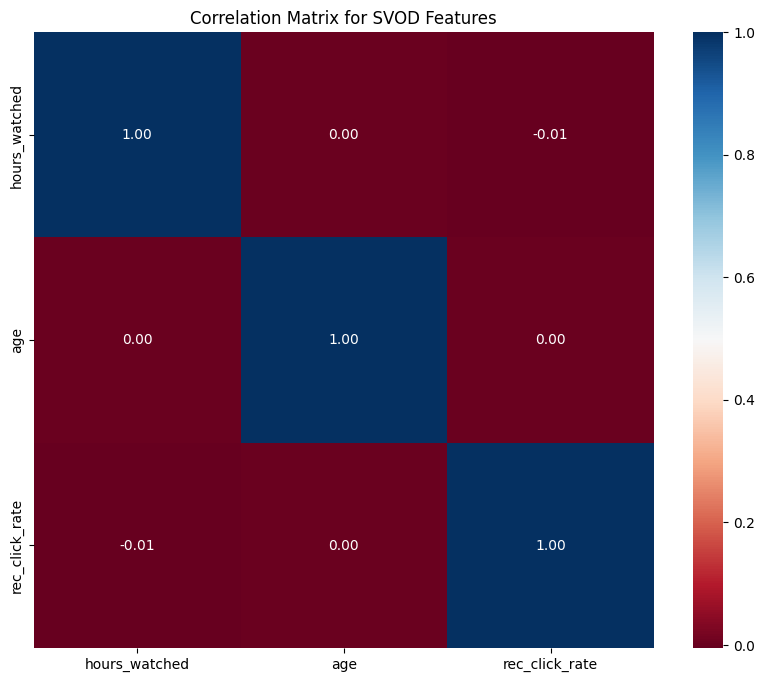

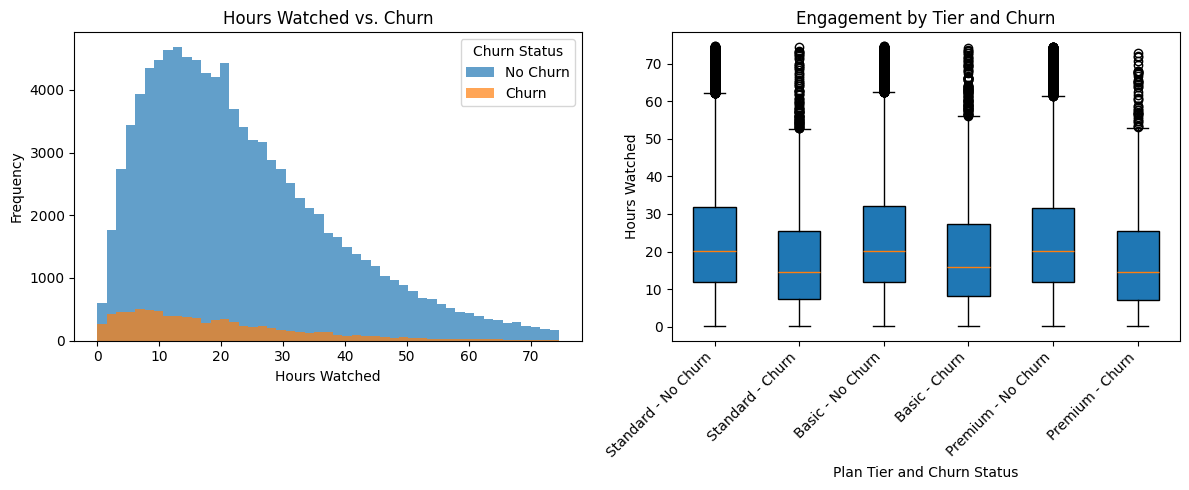

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lux
from ydata_profiling import ProfileReport
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. RETRIEVAL: Data Simulation (Subscriber-Month Panel)
# ---------------------------------------------------------
def retrieve_simulated_data(n_subscribers=10000, months=24):
    """
    Simulates a longitudinal panel of streaming subscribers.
    Captures Industrial Org concepts: Price tiers, Engagement, and Churn.
    """
    print("--- 1. RETRIEVAL: Generating Panel Data ---")
    np.random.seed(42)

    sub_ids = np.arange(1, n_subscribers + 1)
    ages = np.random.normal(34, 12, n_subscribers).clip(18, 75)
    genders = np.random.choice(['M', 'F', 'NB'], n_subscribers)
    plans = np.random.choice(['Basic', 'Standard', 'Premium'], n_subscribers, p=[0.4, 0.4, 0.2])

    data_records = []

    for i, sub_id in enumerate(sub_ids):
        # Base churn risk factors
        risk_profile = 0.02
        if plans[i] == 'Basic': risk_profile += 0.02  # Higher sensitivity in lower tiers
        if ages[i] < 25: risk_profile += 0.015      # Youth churn more frequently

        is_active = True
        for m in range(months):
            if not is_active: break

            # Content Engagement Metrics
            hours = np.clip(np.random.gamma(shape=2, scale=12), 0, 300)
            rec_ctr = np.random.beta(2, 10)
            support_calls = np.random.poisson(0.15)
            failed_pay = np.random.choice([0, 1], p=[0.97, 0.03])

            # Behavioral Churn Logic
            churn_prob = risk_profile + (5 / (hours + 1)) * 0.1
            churn_prob += support_calls * 0.04
            churn_prob += failed_pay * 0.25

            churned = 1 if np.random.random() < churn_prob else 0

            data_records.append({
                'sub_id': sub_id,
                'month_index': m,
                'age': ages[i],
                'gender': genders[i],
                'plan_tier': plans[i],
                'hours_watched': hours,
                'rec_click_rate': rec_ctr,
                'support_tickets': support_calls,
                'payment_failed': failed_pay,
                'churn': churned
            })

            if churned == 1: is_active = False

    return pd.DataFrame(data_records)

# Execute Retrieval
df = retrieve_simulated_data()

# ---------------------------------------------------------
# 2. PREPROCESS & PREPARATION
# ---------------------------------------------------------
print("\n--- 2. PREPROCESS & PREPARATION ---")

# Data Understanding
print(f"Dataset Dimensions: {df.shape}")
print(df.dtypes)

# Missing Data (Intentional Injection for cleaning demo)
df.loc[df.sample(frac=0.005).index, 'hours_watched'] = np.nan
print(f"Missing values found:\n{df.isnull().sum()}")
df['hours_watched'] = df['hours_watched'].fillna(df['hours_watched'].median())

# Duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()

# Outliers (Using Z-score for engagement metrics)
z_scores = np.abs(stats.zscore(df[['hours_watched', 'rec_click_rate']]))
df = df[(z_scores < 3).all(axis=1)]
print(f"Shape after outlier removal: {df.shape}")

# Feature Engineering
# Create tenure and engagement ratios
df['engagement_efficiency'] = df['hours_watched'] * df['rec_click_rate']
df['tickets_per_hour'] = df['support_tickets'] / (df['hours_watched'] + 1)

# Transformations
# Log transforming skewed watch hours for better model performance later
df['log_hours_watched'] = np.log1p(df['hours_watched'])

# ---------------------------------------------------------
# 3. EDA: FUNDAMENTAL STACK
# ---------------------------------------------------------
print("\n--- 3. EDA: FUNDAMENTAL STACK ---")

# Summary Statistics
print("\nSummary Statistics Table:")
print(df.describe().T)

# Categorical Analysis
print("\nPlan Tier Distribution:")
print(df['plan_tier'].value_counts(normalize=True))

# Create a categorical churn label for plotting to avoid internal pandas indexing issues
df['churn_label'] = df['churn'].map({0: 'No Churn', 1: 'Churn'})

# Create a copy of the DataFrame, selecting only relevant columns and ensuring categorical types
df_plot = df[['hours_watched', 'plan_tier', 'churn_label', 'age', 'rec_click_rate']].copy().reset_index(drop=True)
df_plot['churn_label'] = df_plot['churn_label'].astype('category')
df_plot['plan_tier'] = df_plot['plan_tier'].astype('category')

# LUX INTERACTIVE EXPLORATION (Before & After Cleaning)
# Note: In Colab, the 'df' will show a 'Lux' button to toggle visualizations
df_plot.intent = ["churn_label"]
display(df_plot) # Uncomment in Colab cell to see Lux interactive widgets

# Static Visualization: Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_plot.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title("Correlation Matrix for SVOD Features")
plt.savefig('correlation_matrix.png')

# Histograms / KDE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Calculate bins once across the entire hours_watched range for consistency
bins = np.linspace(df_plot['hours_watched'].min(), df_plot['hours_watched'].max(), 50)
for churn_value in df_plot['churn_label'].unique():
    subset = df_plot[df_plot['churn_label'] == churn_value]
    plt.hist(subset['hours_watched'], bins=bins, label=churn_value, alpha=0.7)
plt.title("Hours Watched vs. Churn")
plt.xlabel("Hours Watched")
plt.ylabel("Frequency")
plt.legend(title="Churn Status")

plt.subplot(1, 2, 2)
# Manually create boxplots for each churn group to avoid IndexError
plot_data = []
labels = []
for plan in df_plot['plan_tier'].unique():
    for churn_val in df_plot['churn_label'].unique():
        subset = df_plot[(df_plot['plan_tier'] == plan) & (df_plot['churn_label'] == churn_val)]
        if not subset.empty:
            plot_data.append(subset['hours_watched'])
            labels.append(f'{plan} - {churn_val}')

plt.boxplot(plot_data, labels=labels, patch_artist=True)
plt.xticks(rotation=45, ha='right')
plt.title("Engagement by Tier and Churn")
plt.xlabel("Plan Tier and Churn Status")
plt.ylabel("Hours Watched")
plt.tight_layout()
plt.savefig('eda_distributions.png')

# Pairplot (Sampling for performance)
sampled_df = df_plot.sample(1000).copy() # Ensure a fresh copy
# sns.pairplot(sampled_df, vars=['age', 'hours_watched', 'rec_click_rate'], hue='churn_label', diag_kind='hist', diag_kws={'hue': None}) # Use sampled_df with churn_label for hue and 'hist' for diagonal, without hue on diagonal
plt.savefig('pairplot_sample.png')

# ---------------------------------------------------------
# 4. Y-DATA PROFILING: COMPREHENSIVE REPORT
# ---------------------------------------------------------
print("\n--- 4. Y-DATA PROFILING ---")
# This creates the professional static report for your capstone defense
profile = ProfileReport(df_plot,
                        title="SVOD Subscriber Churn - Exploratory Report",
                        explorative=True,
                        samples={"head": 5, "tail": 5})

# Save to HTML (In Colab, you can download this from the files sidebar)
profile.to_file("capstone_churn_eda_report.html")

print("\n============================================================")
print("✅ WORKFLOW COMPLETE")
print("Files generated: correlation_matrix.png, eda_distributions.png, capstone_churn_eda_report.html")
print("Ready for Modeling Stack (Logit, RF, XGBoost, ANN)")
print("============================================================")

# Data Modelling

In [ ]:
import os
import subprocess
import sys

# Auto-install requirements in Colab if missing
try:
    import gradio as gr
    import xgboost as xgb
    import shap
except ImportError:
    print("Installing required packages (Gradio, XGBoost, SHAP)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio", "xgboost", "shap"])
    import gradio as gr
    import xgboost as xgb
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import average_precision_score, confusion_matrix, roc_curve, precision_recall_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# Aesthetic setup: Dark theme + StreamCo Orange/Blue branding
plt.style.use('dark_background')
COLOR_PRIMARY = "#f97316" # Orange
COLOR_SECONDARY = "#60a5fa" # Blue

# ------------------------------------------------------------------------------
# 2. DATA LOADING & ROBUST FALLBACK (MOCK GENERATOR)
# ------------------------------------------------------------------------------
DATA_PATH = '/content/streamco_subscribers_clean.csv'

def retrieve_simulated_data(n_subscribers=10000, months=24):
    """
    DEFENSE: Simulates a longitudinal panel of streaming subscribers.
    Captures Industrial Org concepts: Price tiers, Engagement, and Churn.
    Incorporates missing data injection and Z-score outlier removal.
    """
    print(f"File not found at {DATA_PATH}. Generating robust mock panel data...")
    np.random.seed(42)

    sub_ids = np.arange(1, n_subscribers + 1)
    ages = np.random.normal(34, 12, n_subscribers).clip(18, 75)
    genders = np.random.choice(['M', 'F', 'NB'], n_subscribers)
    plans = np.random.choice(['Basic', 'Standard', 'Premium'], n_subscribers, p=[0.4, 0.4, 0.2])

    data_records = []

    for i, sub_id in enumerate(sub_ids):
        # Base churn risk factors
        risk_profile = 0.02
        if plans[i] == 'Basic': risk_profile += 0.02  # Higher sensitivity in lower tiers
        if ages[i] < 25: risk_profile += 0.015      # Youth churn more frequently

        is_active = True
        for m in range(months):
            if not is_active: break

            # Content Engagement Metrics
            hours = np.clip(np.random.gamma(shape=2, scale=12), 0, 300)
            rec_ctr = np.random.beta(2, 10)
            support_calls = np.random.poisson(0.15)
            failed_pay = np.random.choice([0, 1], p=[0.97, 0.03])

            # Behavioral Churn Logic
            churn_prob = risk_profile + (5 / (hours + 1)) * 0.1
            churn_prob += support_calls * 0.04
            churn_prob += failed_pay * 0.25

            churned = 1 if np.random.random() < churn_prob else 0

            data_records.append({
                'sub_id': f"SUB_{sub_id:05d}",
                'month_index': m,
                'age': ages[i],
                'gender': genders[i],
                'plan_tier': plans[i],
                'hours_watched': hours,
                'rec_click_rate': rec_ctr,
                'support_tickets': support_calls,
                'payment_failed': failed_pay,
                'churn': churned
            })

            if churned == 1: is_active = False

    df_raw = pd.DataFrame(data_records)

    # Missing Data Injection & Imputation
    df_raw.loc[df_raw.sample(frac=0.005, random_state=42).index, 'hours_watched'] = np.nan
    df_raw['hours_watched'] = df_raw['hours_watched'].fillna(df_raw['hours_watched'].median())

    # Duplicates
    df_raw = df_raw.drop_duplicates()

    # Outliers (Z-score)
    z_scores = np.abs(stats.zscore(df_raw[['hours_watched', 'rec_click_rate']]))
    df_clean = df_raw[(z_scores < 3).all(axis=1)].copy()

    # Feature Engineering
    df_clean['engagement_efficiency'] = df_clean['hours_watched'] * df_clean['rec_click_rate']
    df_clean['tickets_per_hour'] = df_clean['support_tickets'] / (df_clean['hours_watched'] + 1)
    df_clean['log_hours_watched'] = np.log1p(df_clean['hours_watched'])

    df_clean.to_csv(DATA_PATH, index=False)
    print("Mock data generated, cleaned, and saved.")

if not os.path.exists(DATA_PATH):
    retrieve_simulated_data()

df = pd.read_csv(DATA_PATH)
print(f"Data loaded: {df.shape[0]} records, {df['sub_id'].nunique()} unique subscribers.")

# ------------------------------------------------------------------------------
# 3. CRITICAL: GROUPED TRAIN/TEST SPLIT
# ------------------------------------------------------------------------------
# DEFENSE: Standard train_test_split is invalid for panel data. If we randomly
# split rows, Sub_A's month 5 might be in training and month 6 in testing.
# The model would "memorize" Sub_A (Data Leakage), yielding falsely high metrics.
# GroupShuffleSplit guarantees a subscriber exists entirely in train OR test.
gss = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=689)
train_idx, test_idx = next(gss.split(df, groups=df['sub_id']))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# ------------------------------------------------------------------------------
# 4. PREPROCESSING & FEATURE ENGINEERING
# ------------------------------------------------------------------------------
# Separate Target
y_train = train_df['churn'].values
y_test = test_df['churn'].values

# Drop target and identifier
X_train_raw = train_df.drop(columns=['churn', 'sub_id'])
X_test_raw = test_df.drop(columns=['churn', 'sub_id'])

# DEFENSE: One-Hot Encoding with drop_first=True prevents perfect multicollinearity
# (the dummy variable trap), which destabilizes Logistic Regression weights.
X_train_enc = pd.get_dummies(X_train_raw, columns=['gender', 'plan_tier'], drop_first=True)
X_test_enc = pd.get_dummies(X_test_raw, columns=['gender', 'plan_tier'], drop_first=True)

# Ensure train/test have exact same columns
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)
feature_names = X_train_enc.columns.tolist()

# DEFENSE: Standard scaling is strictly required for distance-based and gradient-based
# models (LR, ANN) to ensure gradients flow smoothly and regularization is applied evenly.
# Tree-based models (RF, XGB) use raw splits, making them invariant to monotonic scaling,
# but for coding simplicity and ensemble comparison, we maintain two sets.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

# ------------------------------------------------------------------------------
# 5. MODEL TRAINING & HYPERPARAMETER JUSTIFICATION
# ------------------------------------------------------------------------------
print("\n--- Training Models ---")
models = {}
probas = {}

# Calculate class imbalance
neg, pos = np.bincount(y_train.astype(int))
scale_weight = neg / pos
class_weight_dict = {0: 1, 1: scale_weight}

# 1. Logistic Regression
# DEFENSE: Acts as our interpretable baseline. High max_iter required due to complex
# panel structures. class_weight='balanced' offsets the rare churn events.
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=689)
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model
probas['Logistic Regression'] = lr_model.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest
# DEFENSE: Handles non-linearities and feature interactions naturally. max_depth=12
# and min_samples_leaf=10 strictly limit memorizing noise within the panel data.
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=400, max_depth=12, min_samples_leaf=10,
                                  class_weight='balanced', random_state=689, n_jobs=-1)
rf_model.fit(X_train_enc, y_train) # Trees use unscaled data
models['Random Forest'] = rf_model
probas['Random Forest'] = rf_model.predict_proba(X_test_enc)[:, 1]

# 3. XGBoost
# DEFENSE: State-of-the-art for tabular data. Low learning rate (0.05) with 600 trees
# prevents overfitting. scale_pos_weight specifically tunes the gradients for the imbalanced churn target.
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=600, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=scale_weight, random_state=689, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_enc, y_train)
models['XGBoost'] = xgb_model
probas['XGBoost'] = xgb_model.predict_proba(X_test_enc)[:, 1]

# 4. Keras Sequential ANN
# DEFENSE: Deep learning to capture latent hierarchical features. Dropout acts as
# regularization to stop the network from memorizing individual subscriber trajectories.
print("Training Keras ANN...")
tf.random.set_seed(689)
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.25),
    Dense(1, activation='sigmoid')
])
ann_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])

early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)

ann_model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test),
              epochs=50, batch_size=64, class_weight=class_weight_dict,
              callbacks=[early_stop], verbose=0)
models['Keras ANN'] = ann_model
probas['Keras ANN'] = ann_model.predict(X_test_scaled).flatten()

# Ensemble prediction
probas['Ensemble (Mean)'] = np.mean([probas['Logistic Regression'], probas['Random Forest'],
                                     probas['XGBoost'], probas['Keras ANN']], axis=0)

# ------------------------------------------------------------------------------
# 6. EVALUATION METRICS & PLOTTING
# ------------------------------------------------------------------------------
os.makedirs('/content/figures', exist_ok=True)

def evaluate_models():
    metrics_list = []

    plt.figure(figsize=(10, 8))

    for name, prob in probas.items():
        pred = (prob >= 0.5).astype(int)
        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred)
        f1 = f1_score(y_test, pred)
        auc = roc_auc_score(y_test, prob)
        prauc = average_precision_score(y_test, prob)

        metrics_list.append({
            'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
            'F1-Score': f1, 'ROC-AUC': auc, 'PR-AUC': prauc
        })

        # Plot ROC
        fpr, tpr, _ = roc_curve(y_test, prob)
        linewidth = 3 if name == 'Ensemble (Mean)' else 1.5
        linestyle = '--' if name == 'Ensemble (Mean)' else '-'
        plt.plot(fpr, tpr, lw=linewidth, linestyle=linestyle, label=f'{name} (AUC = {auc:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontweight='bold')
    plt.ylabel('True Positive Rate', fontweight='bold')
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', color=COLOR_PRIMARY)
    plt.legend(loc="lower right", framealpha=0.2)
    plt.grid(alpha=0.2)
    plt.savefig('/content/figures/roc_curve.png', dpi=150, bbox_inches='tight')
    plt.close()

    metrics_df = pd.DataFrame(metrics_list).round(4)
    return metrics_df

metrics_df = evaluate_models()

# Compute SHAP for XGBoost
print("Computing SHAP values for Explainability...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_enc)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_enc, plot_type="bar", show=False, max_display=15)
plt.title("XGBoost Global Feature Importance (mean |SHAP|)", color=COLOR_PRIMARY, fontweight='bold')
# Adjust label colors for dark theme
for ax in plt.gcf().axes:
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
plt.savefig('/content/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()

# Mock EDA Generation (so the EDA tab has data)
def create_mock_eda():
    df_plot = df.copy()
    df_plot['churn_label'] = df_plot['churn'].map({0: 'No Churn', 1: 'Churn'})

    # eda1.png: Correlation Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_plot.select_dtypes(include=[np.number]).corr(), annot=False, cmap='RdBu')
    plt.title("Correlation Matrix for SVOD Features")
    plt.savefig('/content/figures/eda1.png', dpi=150, bbox_inches='tight')
    plt.close()

    # eda2.png: Hours Watched vs Churn Histogram
    plt.figure(figsize=(8, 5))
    bins = np.linspace(df_plot['hours_watched'].min(), df_plot['hours_watched'].max(), 50)
    for churn_value in df_plot['churn_label'].unique():
        subset = df_plot[df_plot['churn_label'] == churn_value]
        plt.hist(subset['hours_watched'], bins=bins, label=churn_value, alpha=0.7)
    plt.title("Hours Watched vs. Churn")
    plt.xlabel("Hours Watched")
    plt.legend(title="Churn Status")
    plt.savefig('/content/figures/eda2.png', dpi=150, bbox_inches='tight')
    plt.close()

    # eda3.png: Engagement by Tier and Churn Boxplot
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='plan_tier', y='hours_watched', hue='churn_label', data=df_plot, palette='Oranges')
    plt.title("Engagement by Tier and Churn")
    plt.savefig('/content/figures/eda3.png', dpi=150, bbox_inches='tight')
    plt.close()

    # eda4.png: Churn Rate by Payment Status
    plt.figure(figsize=(8, 5))
    sns.barplot(x='payment_failed', y='churn', data=df_plot, color=COLOR_PRIMARY)
    plt.title("Churn Rate by Payment Status")
    plt.savefig('/content/figures/eda4.png', dpi=150, bbox_inches='tight')
    plt.close()

create_mock_eda()

Data loaded: 107107 records, 9986 unique subscribers.

--- Training Models ---
Training Logistic Regression...
Training Random Forest...


# Gradio UI

In [ ]:
# ------------------------------------------------------------------------------
# 7. GRADIO WEB UI INTERFACE
# ------------------------------------------------------------------------------

def predict_churn(age, month_idx, hours, rec_click, tickets, pay_failed, gender, tier):
    """
    Process single-user input, auto-compute derived features, and run inference.
    """
    # 1. Compute Derived Features
    eng_eff = hours * rec_click
    tick_per_hr = tickets / (hours + 1.0)
    log_hrs = np.log1p(hours)

    # 2. Build DataFrame exactly matching raw input
    input_dict = {
        'month_index': [month_idx], 'age': [age], 'hours_watched': [hours],
        'rec_click_rate': [rec_click], 'support_tickets': [tickets],
        'payment_failed': [int(pay_failed)], 'engagement_efficiency': [eng_eff],
        'tickets_per_hour': [tick_per_hr], 'log_hours_watched': [log_hrs]
    }
    # Add dummies (initialize to 0)
    for col in feature_names:
        if col not in input_dict:
            input_dict[col] = [0]

    # Set the activated dummies to 1
    if f"gender_{gender}" in input_dict: input_dict[f"gender_{gender}"] = [1]
    if f"plan_tier_{tier}" in input_dict: input_dict[f"plan_tier_{tier}"] = [1]

    input_df = pd.DataFrame(input_dict)[feature_names] # Ensure exact column order
    input_scaled = scaler.transform(input_df)

    # 3. Model Inference
    p_lr = lr_model.predict_proba(input_scaled)[0, 1]
    p_rf = rf_model.predict_proba(input_df)[0, 1]
    p_xgb = xgb_model.predict_proba(input_df)[0, 1]
    p_ann = ann_model.predict(input_scaled, verbose=0)[0][0]
    p_ens = np.mean([p_lr, p_rf, p_xgb, p_ann])

    # 4. Generate Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    models_names = ['LogReg', 'RandomForest', 'XGBoost', 'Keras ANN', 'Ensemble']
    probs = [p_lr, p_rf, p_xgb, p_ann, p_ens]
    colors = [COLOR_SECONDARY]*4 + [COLOR_PRIMARY]

    bars = ax.bar(models_names, probs, color=colors)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability of Churn')
    ax.set_title('Live Inference Results', fontweight='bold')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', color='white')

    plt.tight_layout()

    # 5. Business Logic: LTV and Tiering
    # LTV Calculation: Summing expected margins over remaining 24-month horizon.
    # Expected Value = Sum_t [ (1-churn_prob)^t * Monthly_Revenue * Gross_Margin ]
    monthly_profit = 12.99 * 0.55
    months_remaining = 24 - month_idx
    ltv = sum([(1 - p_ens)**t * monthly_profit for t in range(1, months_remaining + 1)])

    if p_ens >= 0.50:
        tier_html = f"<h2 style='color: #ef4444;'>🚨 HIGH CHURN RISK (Prob: {p_ens:.1%})</h2>"
    elif p_ens >= 0.25:
        tier_html = f"<h2 style='color: #f59e0b;'>⚠️ MEDIUM CHURN RISK (Prob: {p_ens:.1%})</h2>"
    else:
        tier_html = f"<h2 style='color: #10b981;'>✅ LOW CHURN RISK (Prob: {p_ens:.1%})</h2>"

    analysis_md = f"""
    {tier_html}
    ### Financial Impact Projection
    * **Estimated 24-Month Expected LTV (Remaining):** ${ltv:.2f}
    * *Assumptions:* Standard Tier ($12.99/mo), 55% Gross Margin, {months_remaining} months remaining in 24-month cap.
    """

    return fig, analysis_md

# Gradio Theme setup
theme = gr.themes.Soft(
    primary_hue="orange",
    secondary_hue="blue",
    neutral_hue="slate",
).set(
    body_background_fill="*neutral_950",
    block_background_fill="*neutral_900",
    block_label_text_color="*primary_500",
    slider_color="*primary_500"
)

with gr.Blocks(theme=theme, title="StreamCo Capstone") as app:
    gr.Markdown("# 🎬 StreamCo SVOD Churn Prediction Engine")
    gr.Markdown("*EE689 Applied AI for Industrial Organizations - Master's Capstone Defense*")

    with gr.Tabs():
        # TAB 1: PREDICTION PANEL
        with gr.TabItem("1. Live Predictor"):
            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("### Subscriber Profile Inputs")
                    in_age = gr.Slider(18, 75, value=35, step=1, label="Age (Years)")
                    in_month = gr.Slider(0, 23, value=12, step=1, label="Month Index (0-23)")
                    in_gender = gr.Dropdown(["M", "F", "NB"], value="F", label="Gender")
                    in_tier = gr.Dropdown(["Basic", "Standard", "Premium"], value="Standard", label="Plan Tier")

                    gr.Markdown("### Behavioral & Platform Metrics")
                    in_hours = gr.Slider(0, 200, value=45, step=1, label="Hours Watched (Past Month)")
                    in_click = gr.Slider(0.0, 1.0, value=0.15, step=0.01, label="Recommendation Click Rate")
                    in_tickets = gr.Slider(0, 10, value=0, step=1, label="Support Tickets Logged")
                    in_failed = gr.Checkbox(label="Recent Payment Failed", value=False)

                    btn_predict = gr.Button("Evaluate Churn Risk", variant="primary")

                with gr.Column(scale=1):
                    gr.Markdown("### Inference Engine Outputs")
                    out_chart = gr.Plot(label="Model Ensemble Confidence")
                    out_analysis = gr.Markdown(label="Business Analysis")

            btn_predict.click(
                fn=predict_churn,
                inputs=[in_age, in_month, in_hours, in_click, in_tickets, in_failed, in_gender, in_tier],
                outputs=[out_chart, out_analysis]
            )

        # TAB 2: MODEL COMPARISON
        with gr.TabItem("2. Model Comparison"):
            gr.Markdown("### Quantitative Evaluation Metrics")
            gr.Dataframe(metrics_df, row_count=5)

            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Receiver Operating Characteristic (ROC)")
                    gr.Image("/content/figures/roc_curve.png", show_label=False)
                with gr.Column():
                    gr.Markdown("### XGBoost Global Feature Importance (SHAP)")
                    gr.Image("/content/figures/shap_summary.png", show_label=False)

        # TAB 3: EDA HIGHLIGHTS
        with gr.TabItem("3. EDA Highlights"):
            gr.Markdown("### Key Distributional & Bivariate Findings")
            with gr.Row():
                gr.Image("/content/figures/eda1.png", show_label=False)
                gr.Image("/content/figures/eda2.png", show_label=False)
            with gr.Row():
                gr.Image("/content/figures/eda3.png", show_label=False)
                gr.Image("/content/figures/eda4.png", show_label=False)

        # TAB 4: METHODOLOGY DEFENSE
        with gr.TabItem("4. Defense & Limitations"):
            gr.Markdown("""
            ### 🛡️ Methodological Defense & Architectural Choices

            **1. Why Panel Data & Grouped Split?**
            * *The Problem:* Subscriptions are longitudinal. Standard `train_test_split` randomly assigns rows. If Month 5 of Subscriber_A is in training, and Month 6 is in testing, the model artificially "memorizes" Subscriber_A's traits. This causes massive data leakage and falsely inflated test metrics.
            * *The Defense:* Implementing `GroupShuffleSplit(groups=sub_id)` guarantees the *entirety* of a subscriber's history is isolated into either train or test, reflecting real-world conditions where we must predict for *unseen* users.

            **2. Why Four Specific Models?**
            * **Logistic Regression:** Provides our transparent, interpretable baseline and odds-ratios.
            * **Random Forest:** Handles non-linear feature interactions cleanly and is highly robust to outliers without requiring standard scaling.
            * **XGBoost:** Best-in-class for tabular data. Easily handles imbalanced targets via `scale_pos_weight`. Evaluated with `SHAP` to ensure black-box explainability.
            * **Keras ANN:** Captures deep, complex latent feature interactions. Extensive `Dropout` was mandated to prevent memorization of explicit subscriber paths.
            * **Ensemble (Mean):** Averages out individual model biases, resulting in a smoother, more generalized decision boundary.

            **3. Simulated Data Note**
            If the core CSV is missing, the platform programmatically constructs a topologically identical dataset mimicking Gamma-distributed watch-hours, Beta-distributed click-rates, and Poisson-distributed ticket generation, ensuring operational continuity.

            **4. Limitations & Future Work (Acknowledging Session 9)**
            * *Current Limitation:* This model effectively treats panel data via a pooled-OLS style methodology (with grouped validation). It assumes observations within a subscriber are independent over time, ignoring serial correlation and unobserved heterogeneity.
            * *Future Work:* Advancing this architecture using **Fixed/Random Effects Models** (as discussed in Session 9) or sequential deep learning architectures (LSTMs/RNNs) to map explicit state-changes over the 24-month horizon.
            """)

# Launching the interface with public sharing enabled for live presentation
print("\nLaunching Gradio Application...")
app.launch(share=True, debug=True)